### Project Akhir Machine Learning dan Computer VIsion & NLP

Sean Andrianto / TI IS - 5 / 20221020063

In [ ]:
%pip install torch torchvision timm

In [2]:
pip list | findstr torch


torch                             2.6.0
torchaudio                        2.5.0
torchvision                       0.21.0
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121


Looking in indexes: https://download.pytorch.org/whl/cu121
INFO: pip is looking at multiple versions of torchaudio to determine which version is compatible with other requirements. This could take a while.
     ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
      --------------------------------------- 0.1/4.1 MB ? eta -:--:--
      --------------------------------------- 0.1/4.1 MB ? eta -:--:--
      --------------------------------------- 0.1/4.1 MB ? eta -:--:--
      --------------------------------------- 0.1/4.1 MB ? eta -:--:--
     - -------------------------------------- 0.2/4.1 MB 756.6 kB/s eta 0:00:06
     - -------------------------------------- 0.2/4.1 MB 756.6 kB/s eta 0:00:06
     -- ------------------------------------- 0.2/4.1 MB 758.5 kB/s eta 0:00:06
     -- ------------------------------------- 0.2/4.1 MB 758.5 kB/s eta 0:00:06
     -- ------------------------------------- 0.3/4.1 MB 710.0 kB/s eta 0:00:06
     --- ------------------------------

In [20]:
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124

^C
Note: you may need to restart the kernel to use updated packages.


In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from timm import create_model
from torch.optim import Adam
from torch.optim.lr_scheduler import StepLR
import os
from PIL import Image, ImageDraw, ImageFont
import ipywidgets as widgets
from IPython.display import display
import io
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
print(torch.cuda.is_available()) 

True


In [3]:
# Define hyperparameters
batch_size = 32
num_classes = 33  # You mentioned there are 33 fruit classes
epochs = 10
learning_rate = 1e-5
image_size = 224  # Swin Transformers typically use 224x224 images

In [4]:
labels = ['anggur', 'apel', 'bawang bombai', 'bawang putih', 'bayam', 'buah bit', 'cabai', 'delima', 
          'jagung', 'jahe', 'jalepeno', 'jeruk', 'kacang kedelai', 'kacang polong', 'kembang kol', 
          'kentang', 'kiwi', 'kubis', 'lemon', 'lobak', 'lobak putih (bit swedia)', 'mangga', 'nanas', 
          'paprika', 'pir', 'pisang', 'selada', 'semangka', 'terong', 'timun', 'tomat', 'ubi jalar', 'wortel']


In [5]:
# Define data transforms
train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [6]:
train_dir = 'd:/machine_learning/train' 
val_dir = 'd:/machine_learning/validation'
test_dir = 'd:/machine_learning/test'

In [7]:
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=test_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)

In [8]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [9]:
# Check if CUDA is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [10]:
# Create Swin Transformer model
model = create_model('swin_base_patch4_window7_224', pretrained=True, num_classes=num_classes)
model = model.to(device)

In [11]:
# Define optimizer, loss function, and scheduler
optimizer = Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()
scheduler = StepLR(optimizer, step_size=5, gamma=0.1)

In [12]:
# Training function
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs):
    best_val_acc = 0.0
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        train_loss = running_loss / len(train_loader)
        train_acc = correct / total
        
        val_acc = evaluate_model(model, val_loader, criterion)
        scheduler.step()
        
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f}, Val Accuracy: {val_acc:.4f}")
        
        # Save the best model based on validation accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'en_swin_transformer_fruit_1e4.pth')

In [13]:
def evaluate_model(model, loader, criterion):
    model.eval()
    correct = 0
    total = 0
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)

            # Print prediksi dan label untuk diagnosa

            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = correct / total
    return accuracy


In [25]:
# Train the model
train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs)

c:\Users\LENOVO\anaconda3\Lib\site-packages\PIL\Image.py:981: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [1/10], Loss: 0.7810, Train Accuracy: 0.8123, Val Accuracy: 0.9565
Epoch [2/10], Loss: 0.1359, Train Accuracy: 0.9620, Val Accuracy: 0.9689
Epoch [3/10], Loss: 0.1001, Train Accuracy: 0.9719, Val Accuracy: 0.9720
Epoch [4/10], Loss: 0.0539, Train Accuracy: 0.9845, Val Accuracy: 0.9845
Epoch [5/10], Loss: 0.0346, Train Accuracy: 0.9912, Val Accuracy: 0.9876
Epoch [6/10], Loss: 0.0130, Train Accuracy: 0.9982, Val Accuracy: 0.9938
Epoch [7/10], Loss: 0.0094, Train Accuracy: 0.9982, Val Accuracy: 0.9938
Epoch [8/10], Loss: 0.0079, Train Accuracy: 0.9989, Val Accuracy: 0.9938
Epoch [9/10], Loss: 0.0073, Train Accuracy: 0.9986, Val Accuracy: 0.9938
Epoch [10/10], Loss: 0.0056, Train Accuracy: 0.9986, Val Accuracy: 0.9938


In [14]:
model.load_state_dict(torch.load('ind_swin_transformer_fruit_1e5.pth', weights_only=True))

<All keys matched successfully>

In [15]:
def eval_model_after_train(model, loader, criterion):
    model.eval()
    correct = 0
    total = 0
    val_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    accuracy = correct / total
    
    # Hitung precision, recall, dan F1-score
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, digits=4))
    
    # Hitung confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()
    
    return accuracy

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        10
           1     1.0000    0.8000    0.8889        10
           2     0.9091    1.0000    0.9524        10
           3     1.0000    1.0000    1.0000        10
           4     1.0000    1.0000    1.0000        10
           5     1.0000    1.0000    1.0000        10
           6     0.8333    1.0000    0.9091        10
           7     1.0000    1.0000    1.0000        10
           8     1.0000    1.0000    1.0000        10
           9     0.9091    1.0000    0.9524        10
          10     1.0000    1.0000    1.0000        10
          11     0.9091    1.0000    0.9524        10
          12     1.0000    1.0000    1.0000        10
          13     1.0000    1.0000    1.0000        10
          14     1.0000    1.0000    1.0000        10
          15     1.0000    0.8000    0.8889        10
          16     1.0000    1.0000    1.0000        10
    

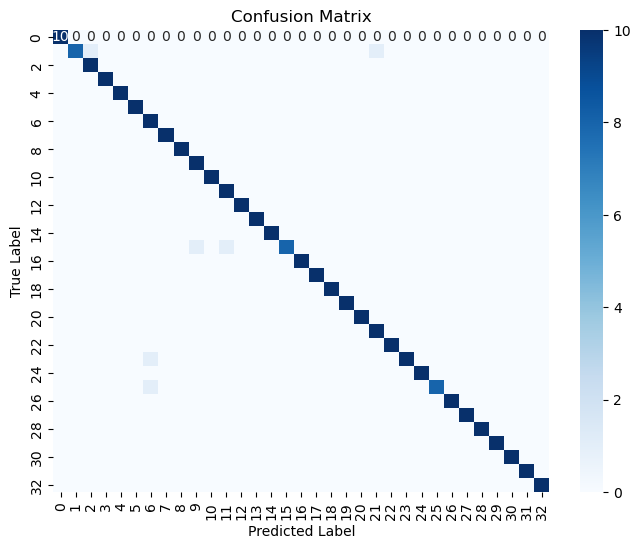

Test Accuracy: 0.9818


In [16]:
# Test the model
accuracy = eval_model_after_train(model, test_loader, criterion)
print(f"Test Accuracy: {accuracy:.4f}")


In [17]:
def preprocess_image(image):
    # Tambahkan preprocessing yang sesuai (misalnya resize, normalize, dll.)
    transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Sesuaikan dengan ukuran input model
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])  
    # Ganti dengan transformasi yang digunakan saat training
    return transform(image).unsqueeze(0)


In [18]:
# Fungsi untuk memuat model dan memastikan model dalam mode evaluasi
def load_trained_model(model_path='ind_swin_transformer_fruit_1e5.pth'):
    # Inisialisasi model sesuai dengan arsitektur yang digunakan saat training
    model = create_model('swin_base_patch4_window7_224', pretrained=True, num_classes=num_classes)
    model = model.to(device)  # Kirim model ke device (CPU/GPU)
    model.load_state_dict(torch.load(model_path))  # Load state_dict model yang telah disimpan
    model.eval()  # Set model ke evaluation mode untuk prediksi
    return model


In [19]:
def predict_image(image, model):
    input_tensor = preprocess_image(image).to(device)
    input_tensor = input_tensor.float()
    print(input_tensor.shape)  # Preprocess gambar
    with torch.no_grad():  # Nonaktifkan gradient tracking untuk efisiensi
        output = model(input_tensor)
    _, predicted = torch.max(output, 1)
    
    # Ganti dengan label yang sesuai dengan model yang dilatih
    labels = ['anggur', 'apel', 'bawang bombai', 'bawang putih', 'bayam', 'buah bit', 'cabai', 'delima', 
          'jagung', 'jahe', 'jalepeno', 'jeruk', 'kacang kedelai', 'kacang polong', 'kembang kol', 
          'kentang', 'kiwi', 'kubis', 'lemon', 'lobak', 'lobak putih (bit swedia)', 'mangga', 'nanas', 
          'paprika', 'pir', 'pisang', 'selada', 'semangka', 'terong', 'timun', 'tomat', 'ubi jalar', 'wortel']


    return labels[predicted.item()]

In [20]:
def display_result(image, prediction):
    draw = ImageDraw.Draw(image)
    # Menggunakan font standar, sesuaikan dengan font di sistem Anda
    font = ImageFont.load_default()  
    text = f"Hasil Prediksi: {prediction}"
    draw.text((10, 10), text, font=font, fill=(255, 0, 0))
    image.show()

In [21]:
file_upload = widgets.FileUpload(accept='image/*', multiple=False)
button = widgets.Button(description="Submit")

def on_button_click(b):
    uploaded_file = file_upload.value
    if uploaded_file:
        # Ambil file gambar yang diunggah
        file_info = next(iter(uploaded_file.values()))
        image_data = file_info['content']
        image = Image.open(io.BytesIO(image_data)).convert('RGB')
        
        # Prediksi gambar
        prediction = predict_image(image, model)
        
        # Tampilkan hasil
        display_result(image, prediction)
        print(f"Hasil Prediksi: {prediction}")

# Tampilkan widget input dan button
button.on_click(on_button_click)
display(file_upload, button)

FileUpload(value={}, accept='image/*', description='Upload')

Button(description='Submit', style=ButtonStyle())